In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Load dataset
food = pd.read_csv('/content/u_food_marketing.csv')
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [3]:
# set rows and columns option
pd.set_option('display.max.columns',50)
pd.set_option('display.max.rows',2300)

In [4]:
food

Output hidden; open in https://colab.research.google.com to view.

In [5]:
# Check for duplicates
food[food.duplicated()].sum()

,0
Income,9366769.0
Kidhome,79.0
Teenhome,87.0
Recency,9277.0
MntWines,55672.0
MntFruits,4936.0
MntMeatProducts,28906.0
MntFishProducts,7256.0
MntSweetProducts,4708.0
MntGoldProds,8380.0


In [6]:
# Drop duplicates
food.drop_duplicates(keep = False,inplace=True)

In [7]:
# Check dataset after removing duplicates
food.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1843 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                1843 non-null   float64
 1   Kidhome               1843 non-null   int64  
 2   Teenhome              1843 non-null   int64  
 3   Recency               1843 non-null   int64  
 4   MntWines              1843 non-null   int64  
 5   MntFruits             1843 non-null   int64  
 6   MntMeatProducts       1843 non-null   int64  
 7   MntFishProducts       1843 non-null   int64  
 8   MntSweetProducts      1843 non-null   int64  
 9   MntGoldProds          1843 non-null   int64  
 10  NumDealsPurchases     1843 non-null   int64  
 11  NumWebPurchases       1843 non-null   int64  
 12  NumCatalogPurchases   1843 non-null   int64  
 13  NumStorePurchases     1843 non-null   int64  
 14  NumWebVisitsMonth     1843 non-null   int64  
 15  AcceptedCmp3          1843

In [8]:
# Create a new column that combine Kid Home and Teen Home
food['Total_Children'] = food[['Kidhome','Teenhome']].sum(axis= 1)

In [9]:
# check dataset after adding new column
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total_Children
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,1,0,0,0,0,1,0,0,1529,1441,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,1,0,0,0,0,1,0,0,21,15,0,2
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,1,0,0,0,1,0,0,734,692,0,0
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,1,0,0,0,1,0,0,48,43,0,1
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,1,0,0,0,0,0,0,0,1,407,392,0,1


In [10]:
# Assign each type of Marital Status into a new number
food['marital_Divorced'] = food['marital_Divorced'].replace({1:5,0:0})
food['marital_Married'] = food['marital_Married'].replace({1:4,0:0})
food['marital_Single'] = food['marital_Single'].replace({1:3,0:0})
food['marital_Together'] = food['marital_Together'].replace({1:2,0:0})
food['marital_Widow'] = food['marital_Widow'].replace({1:1,0:0})

In [11]:
# Combine into one column
food['marital_Status'] = food[['marital_Divorced','marital_Married','marital_Single','marital_Together','marital_Widow']].sum(axis=1)

In [12]:
# Check dataset after adding Marital Status column
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total_Children,marital_Status
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,3,0,0,0,0,1,0,0,1529,1441,0,0,3
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,3,0,0,0,0,1,0,0,21,15,0,2,3
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,2,0,0,0,1,0,0,734,692,0,0,2
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,2,0,0,0,1,0,0,48,43,0,1,2
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,4,0,0,0,0,0,0,0,1,407,392,0,1,4


In [13]:
food[food['marital_Status']!= 0].head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total_Children,marital_Status
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,3,0,0,0,0,1,0,0,1529,1441,0,0,3
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,3,0,0,0,0,1,0,0,21,15,0,2,3
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,2,0,0,0,1,0,0,734,692,0,0,2
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,2,0,0,0,1,0,0,48,43,0,1,2
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,4,0,0,0,0,0,0,0,1,407,392,0,1,4


In [14]:
# Adding marital Status column in String data type
food['Marital_Status_str'] = food['marital_Status'].map({5: 'Divorced', 4:'Married',3:'Single',2:'Together',1:'Widow'})

In [15]:
# check dataset after adding new column
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total_Children,marital_Status,Marital_Status_str
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,3,0,0,0,0,1,0,0,1529,1441,0,0,3,Single
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,3,0,0,0,0,1,0,0,21,15,0,2,3,Single
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,2,0,0,0,1,0,0,734,692,0,0,2,Together
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,2,0,0,0,1,0,0,48,43,0,1,2,Together
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,4,0,0,0,0,0,0,0,1,407,392,0,1,4,Married


In [16]:
# Assign each level of Education into a new number
food['education_PhD'] = food['education_PhD'].replace({1:5,0:0})
food['education_Master'] = food['education_Master'].replace({1:4,0:0})
food['education_Graduation'] = food['education_Graduation'].replace({1:3,0:0})
food['education_Basic'] = food['education_Basic'].replace({1:2,0:0})
food['education_2n Cycle'] = food['education_2n Cycle'].replace({1:1,0:0})

In [17]:
# Combine into one column
food['Education_Status'] = food[['education_PhD','education_Master','education_Graduation','education_Basic','education_2n Cycle']].sum(axis=1)

In [18]:
food[food['Education_Status']!= 0].head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total_Children,marital_Status,Marital_Status_str,Education_Status
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,3,0,0,0,0,3,0,0,1529,1441,0,0,3,Single,3
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,3,0,0,0,0,3,0,0,21,15,0,2,3,Single,3
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,2,0,0,0,3,0,0,734,692,0,0,2,Together,3
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,2,0,0,0,3,0,0,48,43,0,1,2,Together,3
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,4,0,0,0,0,0,0,0,5,407,392,0,1,4,Married,5


In [19]:
# Combine into one column for Accepted Campaigns
food['Accepted_Campaigns'] = food[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)

In [20]:
# Convert the column into binary indicator
food['Accepted_Campaigns'] = (food['Accepted_Campaigns'] != 0).astype(int)

In [21]:
food[food['Accepted_Campaigns'] != 0].head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total_Children,marital_Status,Marital_Status_str,Education_Status,Accepted_Campaigns
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,3,0,0,0,0,3,0,0,1529,1441,0,0,3,Single,3,1
8,30351.0,1,0,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,3,11,1,46,2547,0,0,0,2,0,0,0,0,0,5,44,42,0,1,2,Together,5,1
9,5648.0,1,1,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0,70,2267,0,0,0,2,0,0,0,0,0,5,36,23,1,2,2,Together,5,1
17,76995.0,0,1,91,1012,80,498,0,16,176,2,11,4,9,5,0,0,0,1,0,0,3,11,0,71,2617,0,4,0,0,0,0,0,0,4,0,1606,1430,1,1,4,Married,4,1
21,58607.0,0,1,63,867,0,86,0,0,19,3,2,3,9,8,0,1,0,0,0,0,3,11,0,71,2712,0,4,0,0,0,0,0,0,0,5,953,934,1,1,4,Married,5,1


In [22]:
# Calculate correlation of numerical features in Accepted Campaigns
numerical_food = food.select_dtypes(include=np.number)
display(numerical_food.corr(method = 'pearson')['Accepted_Campaigns'].sort_values(ascending = False))

,Accepted_Campaigns
Accepted_Campaigns,1.000000
AcceptedCmpOverall,0.713352
Response,0.685109
AcceptedCmp4,0.465985
AcceptedCmp3,0.453742
AcceptedCmp5,0.441264
AcceptedCmp1,0.426687
MntWines,0.416651
MntTotal,0.393910
MntRegularProds,0.391931


<Axes: >

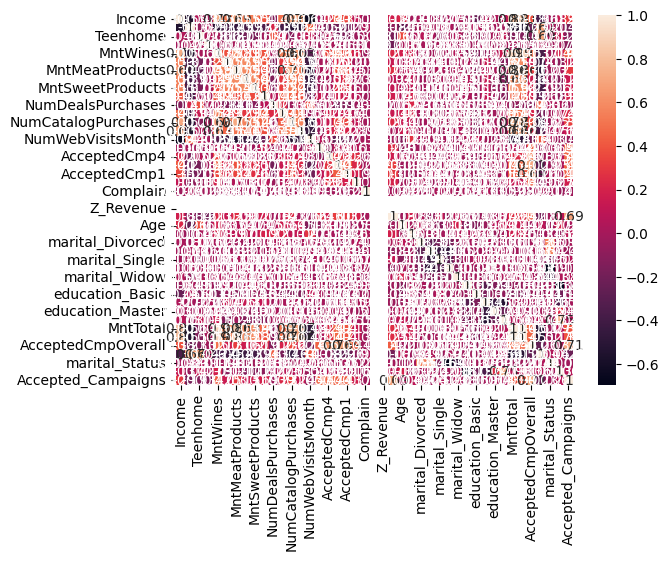

In [23]:
# Creat a heatmap
sns.heatmap(numerical_food.corr(method = 'pearson'),annot=True)
# this is so hard to interpret

<Axes: >

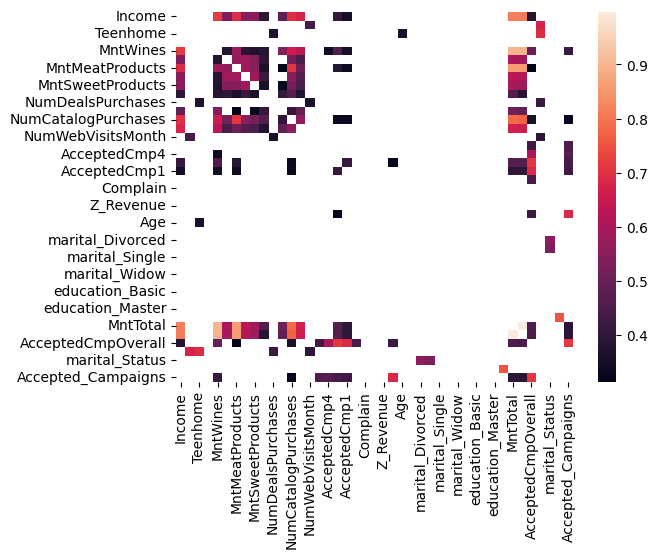

In [24]:
# Filter the correlation for better interpretation
all_correlations = numerical_food.corr(method = 'pearson')
all_correlations = all_correlations[(all_correlations > 0.3) &(all_correlations <1)]

sns.heatmap(all_correlations)

In [25]:
all_correlations['Accepted_Campaigns']

,Accepted_Campaigns
Income,NaN
Kidhome,NaN
Teenhome,NaN
Recency,NaN
MntWines,0.416651
MntFruits,NaN
MntMeatProducts,NaN
MntFishProducts,NaN
MntSweetProducts,NaN
MntGoldProds,NaN


In [26]:
# Check for Age range
food['Age'].sort_values()

# 24-80

,Age
1150,24
43,24
1824,25
727,25
2180,25
400,26
1143,26
894,26
901,27
1330,27


In [27]:
# Create age groups
age_groups = [(23,30), (31,40), (41,50), (51,60),(61,70),(71,85)]

def assign_age_group(Age):
  for age_range in age_groups:
    if age_range[0] <= Age <= age_range[1]:
      return f"{age_range[0]} - {age_range[1]}"
  return("Unknown")

food['Age_Group'] = food['Age'].apply(assign_age_group)

In [28]:
food[['Age','Age_Group']].head()

,Age,Age_Group
0,63,61 - 70
1,66,61 - 70
2,55,51 - 60
3,36,31 - 40
4,39,31 - 40


<Axes: xlabel='Age_Group', ylabel='Accepted_Campaigns'>

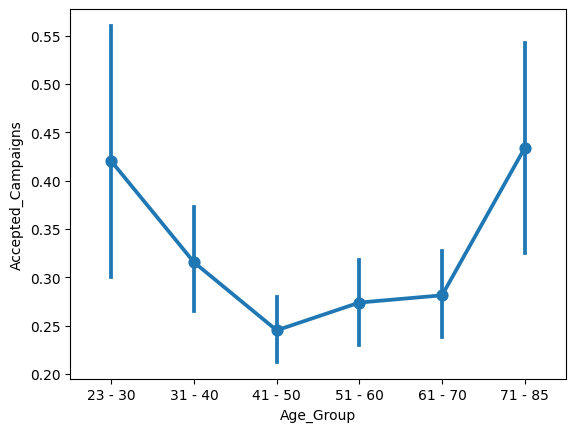

In [29]:
# Create pointplot Accepted Campaigns by Age Group
age_order = ['23 - 30','31 - 40', '41 - 50','51 - 60','61 - 70','71 - 85']
sns.pointplot(data = food, x = 'Age_Group', y = 'Accepted_Campaigns', order = age_order)

In [30]:
# Count the number for each age group
counts = food['Age_Group'].value_counts()

In [31]:
# calculate the percentage
percentage = counts / food.shape[0]

In [32]:
percent_food = percentage.reset_index()

In [33]:
percent_food.columns = ['age_group','percentage']
percent_food = percent_food.sort_values('age_group')
percent_food

,age_group,percentage
5,23 - 30,0.027130
3,31 - 40,0.161693
0,41 - 50,0.332067
1,51 - 60,0.221921
2,61 - 70,0.212154
4,71 - 85,0.045035


Text(0.5, 1.0, 'Percentage of Accepted Campaigns per Age Group')

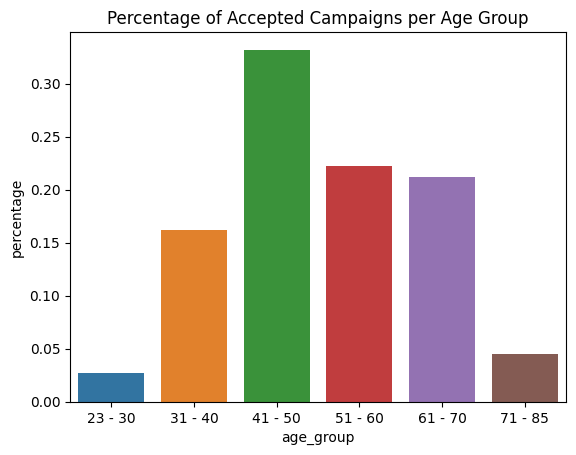

In [34]:
# Create a barplot
sns.barplot(x = 'age_group', y ='percentage', data=percent_food, hue = 'age_group')
plt.title('Percentage of Accepted Campaigns per Age Group')

In [35]:
# Age Segmentation - core audience for accepting campaigns right now is 31-70

Text(0.5, 1.0, 'Amount Spent Per Age Group')

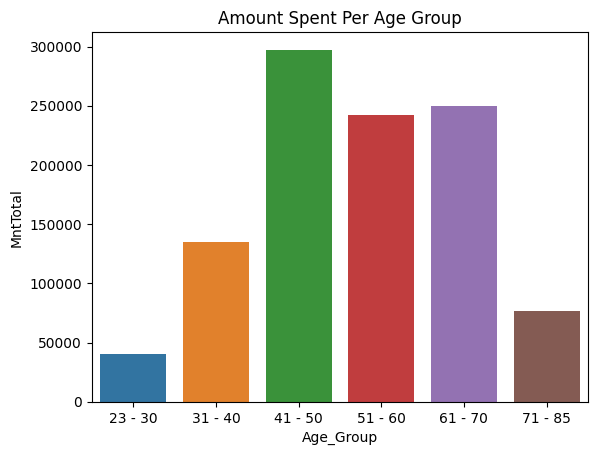

In [36]:
grouped_food = food.groupby('Age_Group')['MntTotal'].sum().reset_index()
sns.barplot(x = 'Age_Group', y ='MntTotal', data= grouped_food, hue = 'Age_Group')
plt.title('Amount Spent Per Age Group')

Text(0.5, 1.0, 'Amount Spent Per Age Group')

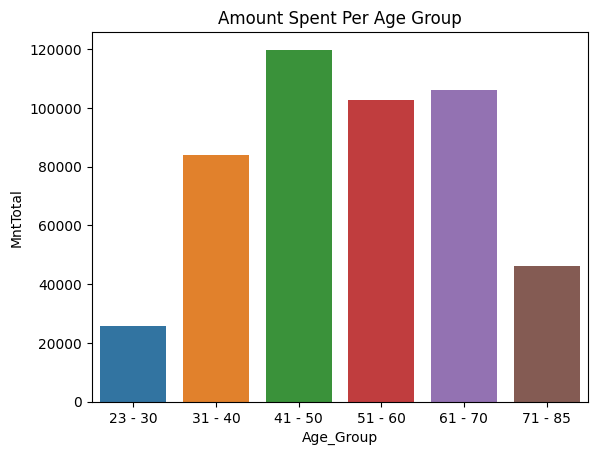

In [37]:
acct_camp = food[food['Accepted_Campaigns'] != 0]

grouped_food = acct_camp.groupby('Age_Group')['MntTotal'].sum().reset_index()
sns.barplot(x = 'Age_Group', y ='MntTotal', data= grouped_food, hue = 'Age_Group')
plt.title('Amount Spent Per Age Group')

In [38]:
# Age Segmentation - core audience for accepting campaigns right now is 31-70. 23-30, 71 and up accept at higher rate

In [42]:
# Cehck for total purchases of each type of purchase
sum_food = pd.DataFrame(food[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(), columns = ['Sums'])
sum_food = sum_food.reset_index()

# Change the column name from index to Typr of Purchase
sum_food.rename(columns = {'index': 'Type_of_Purchase'}, inplace = True)
sum_food

,Type_of_Purchase,Sums
0,NumWebPurchases,7619
1,NumCatalogPurchases,4871
2,NumStorePurchases,10675


<Axes: xlabel='Type_of_Purchase', ylabel='Sums'>

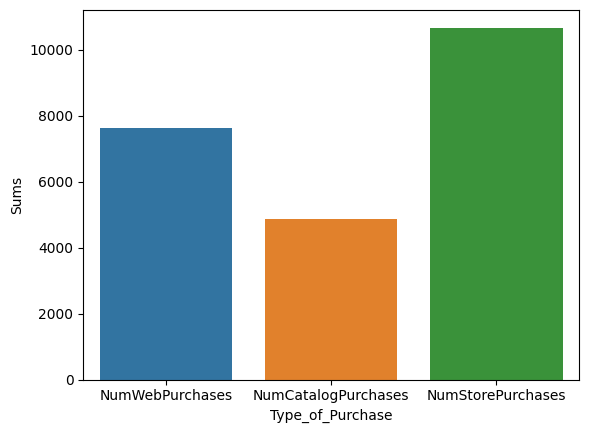

In [44]:
# Create barplot to visualize type of purchase and sums
sns.barplot( x = 'Type_of_Purchase', y ='Sums', data = sum_food, hue = 'Type_of_Purchase' )

<Axes: xlabel='Type_of_Purchase', ylabel='Sums'>

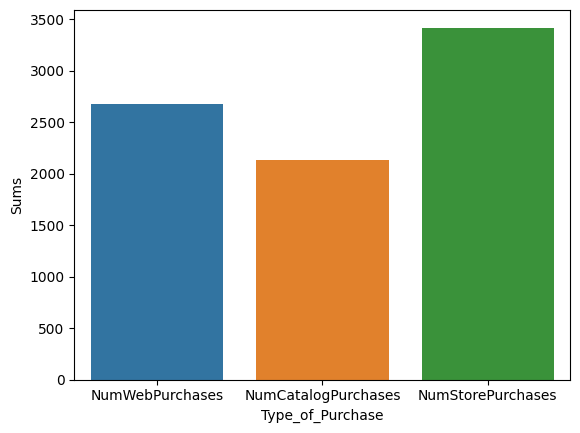

In [45]:
# Filter down to customer who accept the campaigns

acct_camp = food[food['Accepted_Campaigns'] != 0]

sum_food = pd.DataFrame(acct_camp[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(), columns = ['Sums'])
sum_food = sum_food.reset_index()

# Change the column name from index to Typr of Purchase
sum_food.rename(columns = {'index': 'Type_of_Purchase'}, inplace = True)

# Visualizing
sns.barplot( x = 'Type_of_Purchase', y ='Sums', data = sum_food, hue = 'Type_of_Purchase' )

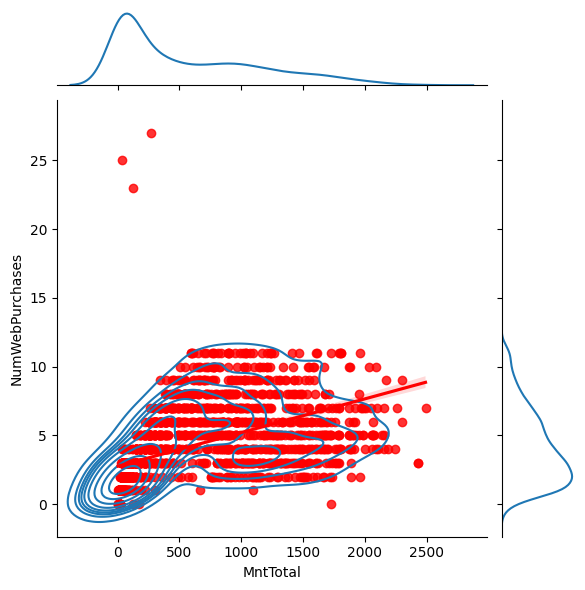

In [48]:
# Create a jointplot between MntTotal and NumWebPurchases
x = sns.jointplot(data = food, x ='MntTotal', y ='NumWebPurchases', kind = "kde")
x.plot_joint(sns.regplot, color = 'r')

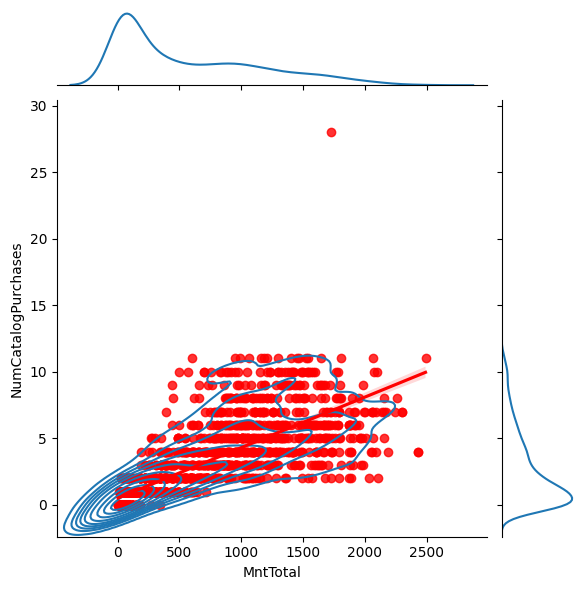

In [49]:
# Create a jointplot between MntTotal and NumCatalogPurchases
x = sns.jointplot(data = food, x ='MntTotal', y ='NumCatalogPurchases', kind = "kde")
x.plot_joint(sns.regplot, color = 'r')

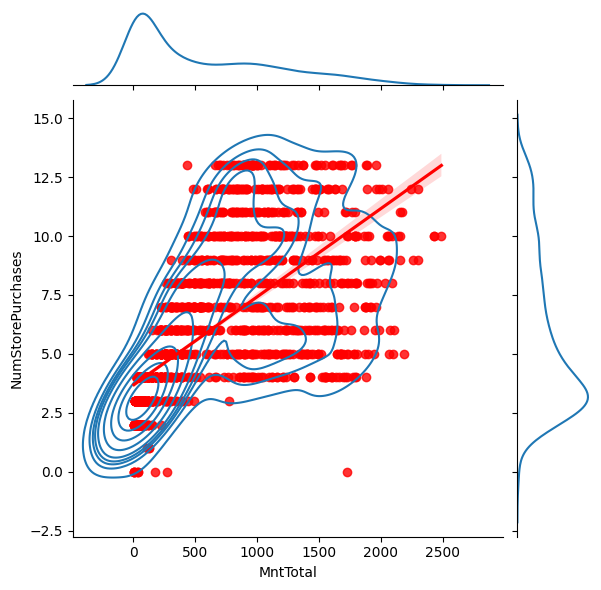

In [50]:
# Create a jointplot between MntTotal and NumStorePurchases
x = sns.jointplot(data = food, x ='MntTotal', y ='NumStorePurchases', kind = "kde")
x.plot_joint(sns.regplot, color = 'r')

In [ ]:
# @ directions: Boost up the higher percentage catalog customers OR focus on In Store/Web because they have more traffic

<Axes: xlabel='Total_Children', ylabel='MntTotal'>

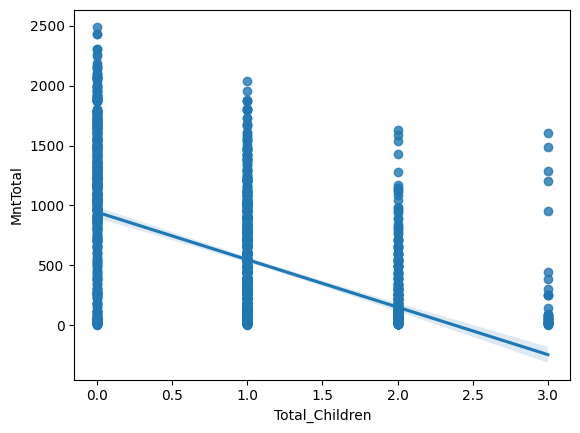

In [53]:
# Create regplot to see total children with amount spent

sns.regplot(x = 'Total_Children', y = 'MntTotal', data = food)

<Axes: xlabel='Total_Children', ylabel='Accepted_Campaigns'>

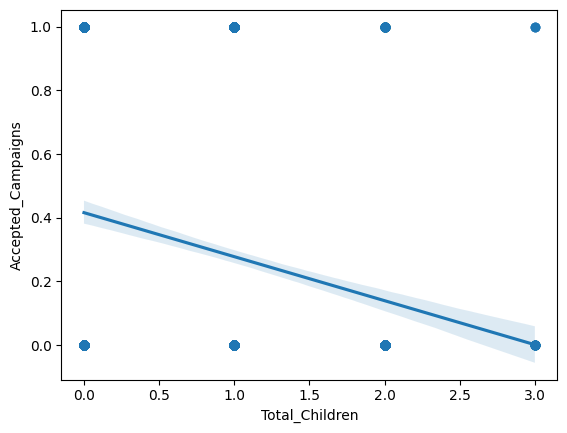

In [54]:
# Create regplot to see total children with accepted campaigns

sns.regplot(x = 'Total_Children', y = 'Accepted_Campaigns', data = food)

In [ ]:
# LEss kids = More likely to accept campaign

<Axes: xlabel='Education_Status', ylabel='Accepted_Campaigns'>

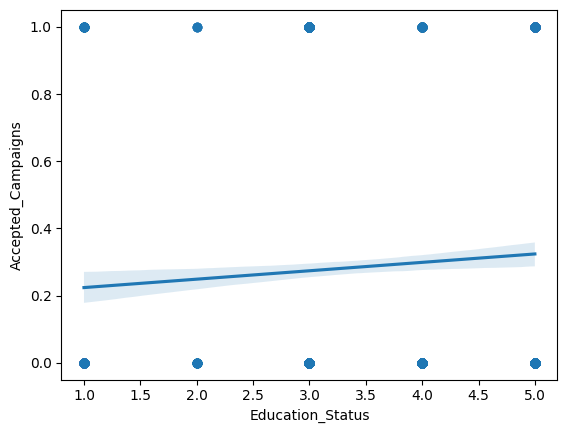

In [55]:
# Create regplot to see Education Status with accepted campaigns
sns.regplot(x = 'Education_Status', y = 'Accepted_Campaigns', data = food)

<Axes: xlabel='Education_Status', ylabel='MntTotal'>

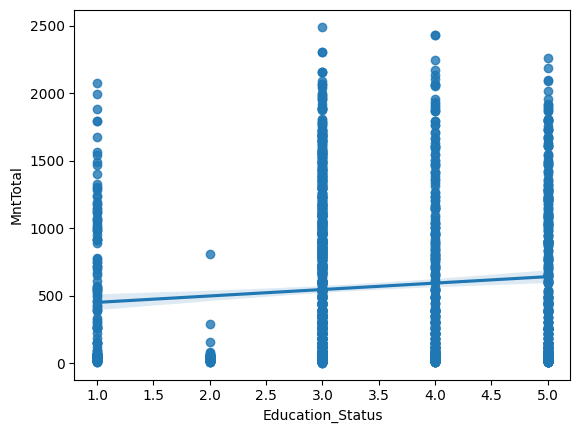

In [56]:
# Create regplot to see Education Status with Amount Total
sns.regplot(x = 'Education_Status', y = 'MntTotal', data = food)

In [ ]:
# Education is not really significant on our segmentation

<Axes: xlabel='Marital_Status_str', ylabel='count'>

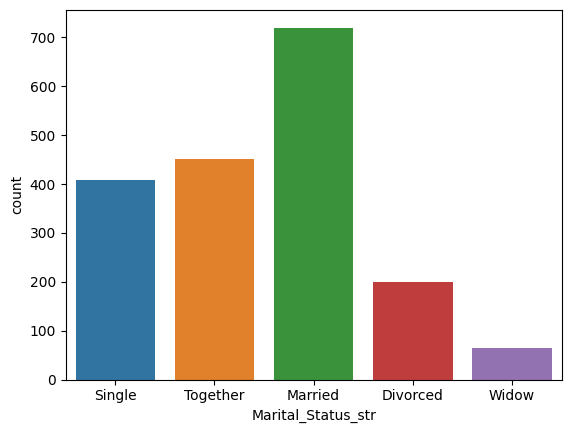

In [57]:
# Create a countplot
sns.countplot(x='Marital_Status_str', data= food, hue = 'Marital_Status_str')

<Axes: xlabel='marital_Status', ylabel='MntTotal'>

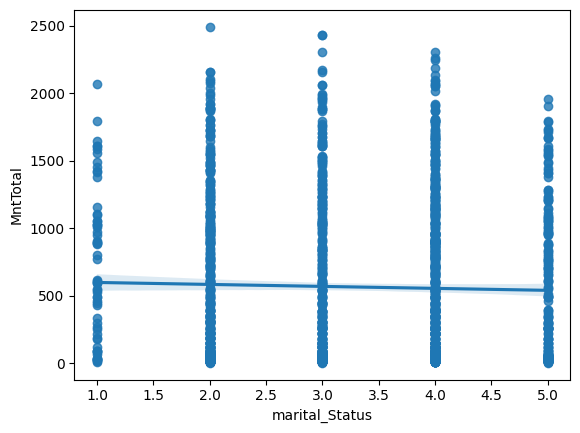

In [61]:
# Create regplot to see Marital Status with MntTotal
# regplot only take numerical values
sns.regplot(x = 'marital_Status', y = 'MntTotal', data = food)

<Axes: xlabel='Marital_Status_str', ylabel='MntTotal'>

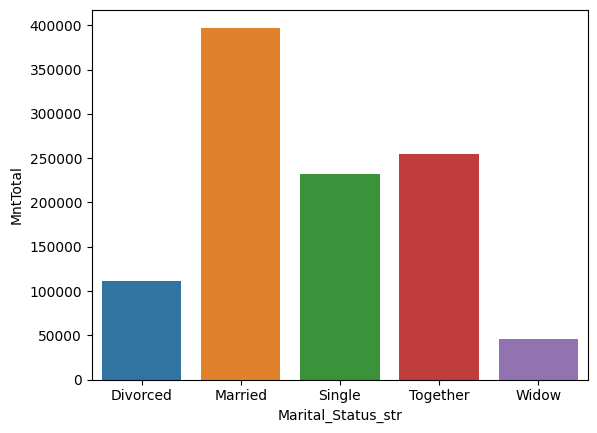

In [69]:
# Bar plot viz between marital status and amount total
rel_food = food.groupby('Marital_Status_str')['MntTotal'].sum().reset_index()
sns.barplot(x='Marital_Status_str', y='MntTotal', data=rel_food, hue = 'Marital_Status_str')

<Axes: xlabel='Marital_Status_str', ylabel='MntTotal'>

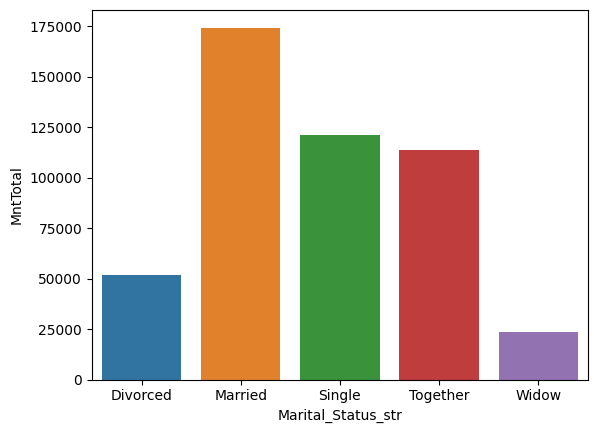

In [68]:
# Filter down to people who accpeted campaigns

accpt = food[food['Accepted_Campaigns'] != 0]
rel_food = accpt.groupby('Marital_Status_str')['MntTotal'].sum().reset_index()
sns.barplot(x='Marital_Status_str', y='MntTotal', data=rel_food, hue = 'Marital_Status_str')


In [71]:
food['Marital_Status_str'].value_counts()

,count
Marital_Status_str,
Married,720
Together,451
Single,409
Divorced,199
Widow,64


In [73]:
total = food['Marital_Status_str'].value_counts()
accepted = food[food['Accepted_Campaigns'] ==1]['Marital_Status_str'].value_counts()

In [74]:
pect_marital = accepted/total * 100

In [77]:
pect_food = pect_marital.reset_index()
pect_food.columns = ['Marital_Status', 'Percentage']  # change columns name

<Axes: xlabel='Marital_Status', ylabel='Percentage'>

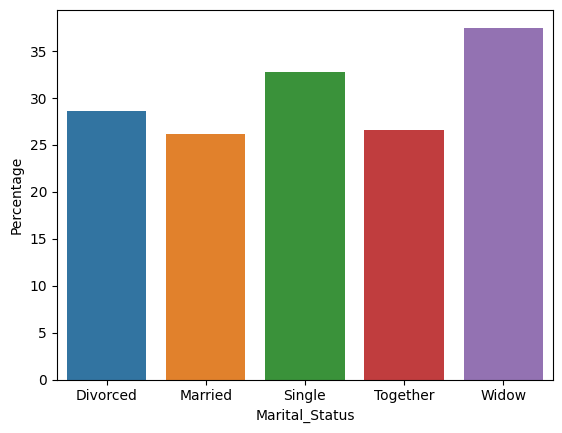

In [79]:
# Visualiztion
sns.barplot(x='Marital_Status', y='Percentage', data= pect_food, hue = 'Marital_Status')

In [ ]:
#Marriage - Married, Signle, together are spedning a lot more money than widow and divored. We should focus on this segment

# Overall Findings:
1. Age:  30-70 were spending more money but less likley to accept campaigns. Higher volume here though.
2. Catalog was more likely to accept campaigns but in person spend more. Recommend a split between all.
- 40% catalog, 30% store, 30% web
3. Focus on people with no kids (or less kids)
4. Education: no impact so do not target any group
5. Marital Status: do not play a big part. Married, Single, Together spend more money


# Money Making:
1. Middle Aged People, High Earners, with no kids. Target on different platforms with split above

# New Users to Spend Money:
1. Focus on 21-30, 70 and up who statitically accepted campaigns at a higher rate